# Logistic Regression Sybil Detector — LayerZero

Baseline linear classifier (the paper's LR configuration; not tuned).

**Configuration**: `C=0.01`, L1 regularisation, `liblinear` solver, `StandardScaler`

**Results**: test metrics are printed in section 6 and saved to
`results/03_logistic_regression_<split>.json`.

> LR serves as a lower bound confirming that the Sybil decision boundary is non-linear. The high AUROC relative to F1 reflects that the model ranks addresses well but cannot separate them sharply at any single threshold.

## 1. Setup

In [1]:
# Install required packages (run once)
# !pip install xgboost lightgbm scikit-learn pandas numpy matplotlib

In [2]:
import os, time, warnings, gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    precision_recall_curve, roc_curve, auc,
    f1_score, precision_score, recall_score,
    confusion_matrix, classification_report,
    brier_score_loss, average_precision_score
)

import sybil_pipeline as sp

warnings.filterwarnings('ignore')
SEED = sp.SEED

In [3]:
# ── Set this to the folder containing all data files ──────────
DATA_DIR = './data'   # <-- adjust if needed

# 'group'  = stratified group split by funding cluster (revision default)
# 'random' = address-level split used in the original paper
SPLIT_METHOD = os.environ.get('SPLIT_METHOD', 'group')

FEATS = sp.FEATS   # 62 model features (defined in sybil_pipeline.py)
print(f'Split method: {SPLIT_METHOD}  |  {len(FEATS)} features')

DATA_DIR : ./data
Features : 63


## 2. Data Loading

In [13]:
# ── Build the master feature table (steps 1-7; see 00_data_pipeline) ──
df, tfm, labeled_anchors = sp.build_master_df(DATA_DIR)

[1] L0 features: 434,786 addresses, 55 cols  (6.7s)
[2] Gas provision: 604,661 mappings  (2.8s)


## 3. Train / Validation / Test Split

In [14]:
# ── Train / Val / Test split + minority upsampling ────────────
# 49 / 21 / 30 partitions. With SPLIT_METHOD='group', no funding group
# spans two partitions (asserted inside sp.make_splits).
S = sp.make_splits(df, FEATS, method=SPLIT_METHOD, seed=SEED)
X_train, y_train = S['X_train'], S['y_train']
X_val,   y_val   = S['X_val'],   S['y_val']
X_test,  y_test  = S['X_test'],  S['y_test']

print(sp.split_summary(df, S).to_string(index=False))
print(f'Train after upsampling: {len(X_train):,} rows ({y_train.mean()*100:.1f}% Sybil)\n')
leak = sp.leakage_report(df, S)

Train (balanced) : 408,242  (50.0% Sybil)
Validation       : 91,305   (4.19% Sybil)
Test             : 130,437  (4.19% Sybil)


## 4. Evaluation Helpers

In [15]:
# ── Evaluation helpers ────────────────────────────────────────
def optimal_threshold(y_true, probs):
    """Find threshold that maximises F1 on the given set."""
    prec, rec, thresholds = precision_recall_curve(y_true, probs)
    f1 = np.where((prec + rec) > 0, 2 * prec * rec / (prec + rec), 0)
    return float(thresholds[np.argmax(f1[:-1])])

def evaluate(name, val_probs, test_probs, y_val, y_test, threshold=None):
    """Evaluate model at optimal val threshold, report test metrics."""
    thr = threshold if threshold is not None else optimal_threshold(y_val, val_probs)
    y_pred = (test_probs >= thr).astype(int)
    fpr, tpr, _ = roc_curve(y_test, test_probs)
    prc, rec, _ = precision_recall_curve(y_test, test_probs)
    results = dict(
        name      = name,
        threshold = thr,
        precision = precision_score(y_test, y_pred, zero_division=0),
        recall    = recall_score(y_test, y_pred,    zero_division=0),
        f1        = f1_score(y_test, y_pred,         zero_division=0),
        auroc     = auc(fpr, tpr),
        ap        = average_precision_score(y_test, test_probs),
        brier     = brier_score_loss(y_test, test_probs),
        fpr=fpr, tpr=tpr, prc=prc, rec_c=rec,
    )
    print(f'  Threshold : {thr:.4f}')
    print(f'  Precision : {results["precision"]:.4f}')
    print(f'  Recall    : {results["recall"]:.4f}')
    print(f'  F1        : {results["f1"]:.4f}')
    print(f'  AUROC     : {results["auroc"]:.4f}')
    print(f'  Avg Prec  : {results["ap"]:.4f}')
    print(f'  Brier     : {results["brier"]:.4f}')
    print(classification_report(y_test, y_pred, digits=4))
    return results

def plot_curves(results_list):
    """Plot ROC and PR curves for one or more models."""
    colors = ['#1565C0','#2E7D32','#B71C1C','#6A1B9A','#E65100']
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    for r, c in zip(results_list, colors):
        axes[0].plot(r['fpr'], r['tpr'], color=c, lw=2,
                     label=f"{r['name']}  AUC={r['auroc']:.4f}")
        axes[1].plot(r['rec_c'], r['prc'], color=c, lw=2,
                     label=f"{r['name']}  AP={r['ap']:.4f}")
    axes[0].plot([0,1],[0,1],'k--',alpha=0.3,lw=1)
    axes[0].set(xlabel='FPR', ylabel='TPR', title='ROC Curve')
    axes[0].legend(fontsize=9); axes[0].grid(alpha=0.2)
    axes[1].set(xlabel='Recall', ylabel='Precision', title='Precision-Recall Curve')
    axes[1].legend(fontsize=9, loc='upper right'); axes[1].grid(alpha=0.2)
    plt.tight_layout(); plt.show()

## 5. Train Logistic Regression

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# ── Parameters match paper's baseline ─────────────────────────
# LR is a linear model trained on the same balanced, upsampled data.
# StandardScaler is mandatory: gradient-based solvers are scale-sensitive.
# C=0.01 (strong L1 regularisation) induces sparsity; only ~20-30 of
# the features receive non-zero weights, improving interpretability.
LR_PARAMS = dict(
    C          = 0.01,
    penalty    = 'l1',
    solver     = 'liblinear',   # required for L1
    max_iter   = 1000,
    random_state = SEED,
)

print('Training Logistic Regression (C=0.01, L1, liblinear)...')
t0 = time.time()
lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('lr',     LogisticRegression(**LR_PARAMS)),
])
lr_pipe.fit(X_train, y_train)
print(f'Done in {time.time()-t0:.1f}s')

lr_val_probs  = lr_pipe.predict_proba(X_val)[:,1]
lr_test_probs = lr_pipe.predict_proba(X_test)[:,1]

Training Logistic Regression (C=0.01, L1, liblinear)...
Done in 49.5s


## 6. Evaluate on Test Set

=== Logistic Regression — Test Set Results ===
  Threshold : 0.7122
  Precision : 0.1506
  Recall    : 0.5299
  F1        : 0.2346
  AUROC     : 0.8335
  Avg Prec  : 0.1590
  Brier     : 0.1787
              precision    recall  f1-score   support

           0     0.9769    0.8694    0.9200    124974
           1     0.1506    0.5299    0.2346      5463

    accuracy                         0.8551    130437
   macro avg     0.5638    0.6996    0.5773    130437
weighted avg     0.9423    0.8551    0.8913    130437



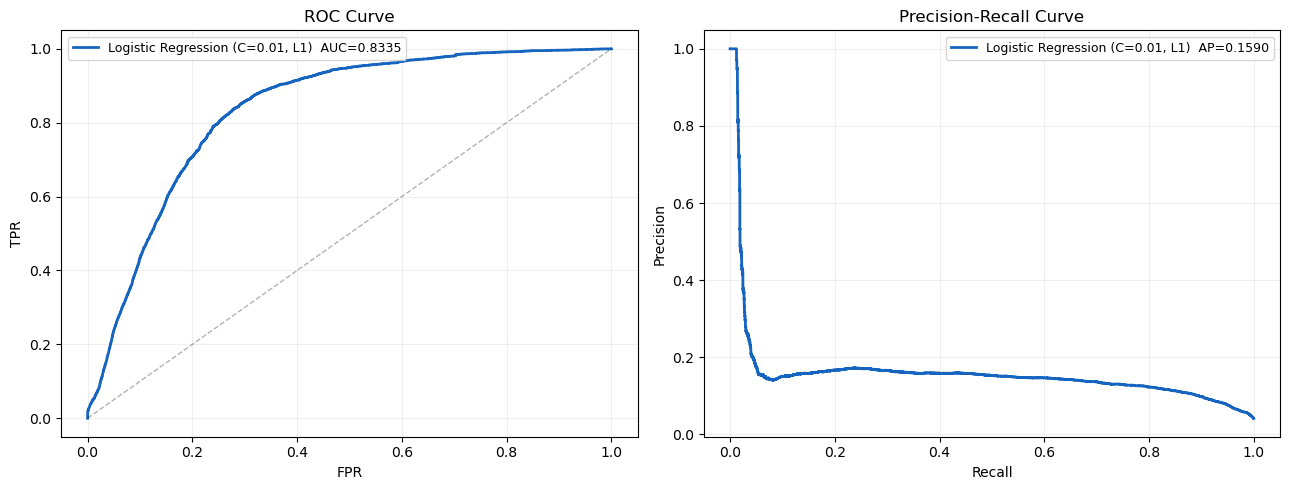

In [17]:
print('=== Logistic Regression — Test Set Results ===')
lr_results = evaluate('Logistic Regression (C=0.01, L1)',
                       lr_val_probs, lr_test_probs, y_val, y_test)
plot_curves([lr_results])

## 7. Non-Zero Coefficients

Non-zero coefficients: 51 / 63
                             Feature  Coefficient
              breadth_to_depth_ratio    -0.890747
                     l0_tx_time_span     0.880731
                 provider_is_labeled     0.565249
                           avg_depth     0.524647
                        time_span_in    -0.514929
            gas_distribution_entropy     0.421294
                  n_eth_interactions    -0.420139
       n_l0_project_per_source_chain    -0.405041
                        cex_in_count    -0.301797
                 num_transactions_in    -0.294472
                  n_l0_source_chains     0.294103
               n_l0_source_contracts    -0.275449
           n_l0_to_eth_source_chains    -0.265607
                           tree_size    -0.250709
                      balance_factor    -0.238767
                       n_l0_projects     0.238754
 provider_total_gas_provision_amount     0.230940
       leaf_gas_distribution_entropy     0.226584
                   

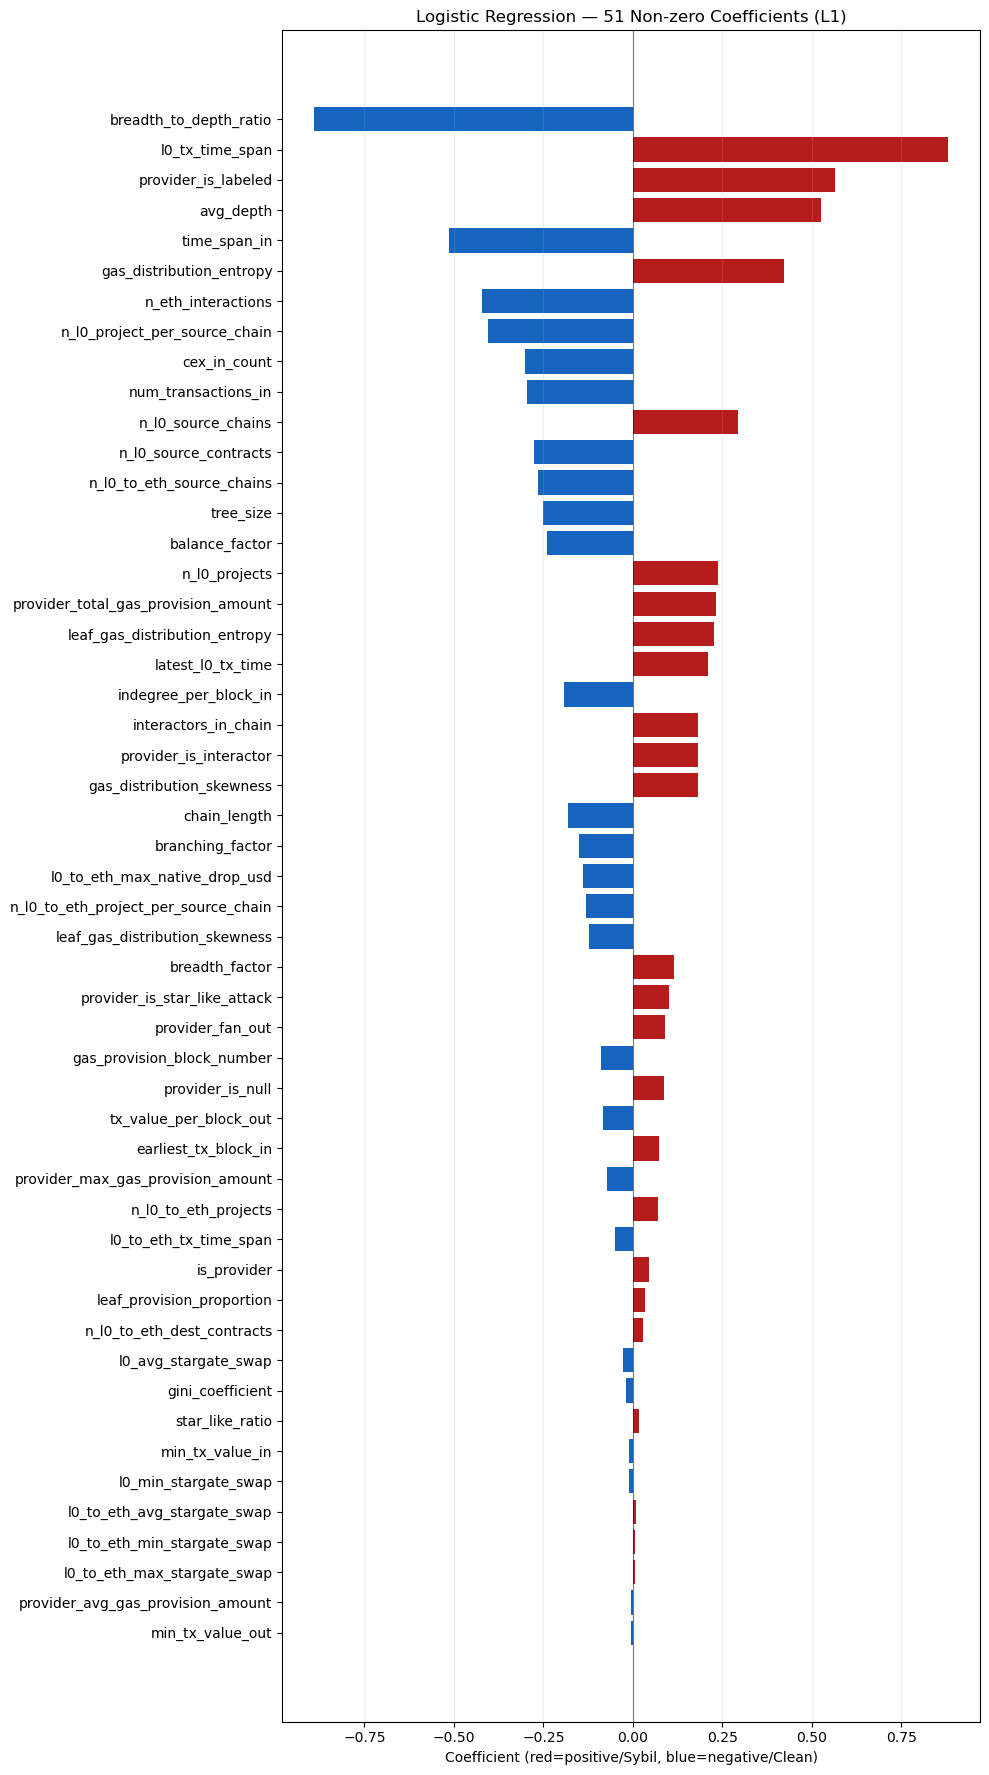

In [18]:
# ── Non-zero coefficients (L1 sparsity) ───────────────────────
coef  = lr_pipe.named_steps['lr'].coef_[0]
nz    = [(FEATS[i], coef[i]) for i in range(len(FEATS)) if coef[i] != 0]
nz_df = pd.DataFrame(nz, columns=['Feature', 'Coefficient'])
nz_df = nz_df.reindex(nz_df['Coefficient'].abs().sort_values(ascending=False).index)

print(f'Non-zero coefficients: {len(nz_df)} / {len(FEATS)}')
print(nz_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, max(5, len(nz_df)*0.35)))
colors = ['#B71C1C' if v > 0 else '#1565C0' for v in nz_df['Coefficient']]
ax.barh(nz_df['Feature'][::-1], nz_df['Coefficient'][::-1], color=colors[::-1])
ax.axvline(0, color='black', lw=0.8, alpha=0.5)
ax.set(xlabel='Coefficient (red=positive/Sybil, blue=negative/Clean)',
       title=f'Logistic Regression — {len(nz_df)} Non-zero Coefficients (L1)')
ax.grid(axis='x', alpha=0.2)
plt.tight_layout(); plt.show()

## Note on LR performance

Logistic Regression scores well below the gradient-boosted models on F1 (see section 6 and
`06_split_comparison`), although its AUROC is moderate. This confirms the Sybil decision boundary is **non-linear**:
the behavioral signals (timing, gas topology, cross-chain breadth) interact in ways
that a linear classifier cannot fully capture.

LR is included as a baseline, not a practical deployment choice for this task.

## Save Results

Scalar metrics go to `results/<notebook>_<split>.json` with the code commit, so every number in the paper can be traced to one run.

In [ ]:
sp.save_results([lr_results], '03_logistic_regression', SPLIT_METHOD, leakage=leak,
                extra=dict(params={k: v for k, v in LR_PARAMS.items()}))

# ── Test predictions (read by 06_split_comparison for per-category metrics) ──
os.makedirs('output', exist_ok=True)
pred = pd.DataFrame({'addr': df.loc[S['idx_test'], 'addr'].to_numpy(),
                     'category': df.loc[S['idx_test'], 'category'].to_numpy(),
                     'y': y_test.to_numpy(), 'prob_lr': lr_test_probs})
pred.to_parquet(f'output/pred_03_logistic_regression_{SPLIT_METHOD}.parquet', index=False)
print(f'Saved output/pred_03_logistic_regression_{SPLIT_METHOD}.parquet ({len(pred):,} rows)')